<a href="https://colab.research.google.com/github/naman-0804/learning/blob/deep-learning/deeplearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
#pip install tensorflow

In [152]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [153]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [154]:
dataset=pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [155]:
##Divide the dataset into independent and dependent features
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

In [156]:
X.head() ##independent feature

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [157]:
y.head() ##dependent feature

,Exited
0,1
1,0
2,1
3,0
4,0


In [158]:
##takes distinct values in that coloumn and makes a binary table of that (present in which row) drop_first removes 1st coloumn , if other two are  0 0 means 1st is 1
geography=pd.get_dummies(X['Geography'],drop_first=True)
gender=pd.get_dummies(X['Gender'],drop_first=True)


In [159]:
##Concatenate these var with data frame
X=X.drop(['Geography','Gender'],axis=1) ##axis removes coloumn

In [160]:
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,42,2,0.00,1,1,1,101348.88
1,608,41,1,83807.86,1,0,1,112542.58
2,502,42,8,159660.80,3,1,0,113931.57
3,699,39,1,0.00,2,0,0,93826.63
4,850,43,2,125510.82,1,1,1,79084.10


In [161]:
X=pd.concat([X,geography,gender],axis=1) ##removed 2 coloumns efficiently
X.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False


In [162]:
##Splitting the dataset into training set and Test set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)


In [163]:
#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)


In [164]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [165]:
X_train.shape

(8000, 11)

## **Part 2 , ANN**

In [166]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

In [167]:
# initialize the ANN
classifier=Sequential()

In [168]:
# Adding the input layer
classifier.add(Dense(units=11,activation='relu'))

In [169]:
#adding first hidden layer
classifier.add(Dense(units=7,activation='relu'))
classifier.add(Dropout(0.3))

In [170]:
#adding second hidden layer
classifier.add(Dense(units=6,activation='relu'))

In [171]:
#adding output layer
classifier.add(Dense(units=1,activation='sigmoid'))

In [172]:
#compile
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [173]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000) #no need for 1000 as stable acc so stop at somwehere

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.7667 - loss: 0.5526 - val_accuracy: 0.7955 - val_loss: 0.4742
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7981 - loss: 0.4723 - val_accuracy: 0.7963 - val_loss: 0.4498
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8065 - loss: 0.4501 - val_accuracy: 0.8027 - val_loss: 0.4338
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8095 - loss: 0.4358 - val_accuracy: 0.8114 - val_loss: 0.4226
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8164 - loss: 0.4203 - val_accuracy: 0.8190 - val_loss: 0.4108
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8294 - loss: 0.4076 - val_accuracy: 0.8262 - val_loss: 0.4016
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8283 - loss: 0.3982 - val_accuracy: 0.8342 - val_loss: 0.3924
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8345 - loss: 0.3910 - 

KeyboardInterrupt: 

In [174]:
#early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping=EarlyStopping(monitor='val_loss',min_delta=0.0001,patience=20,verbose=1,mode='auto',restore_best_weights=False)

In [175]:
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8421 - loss: 0.3746 - val_accuracy: 0.8417 - val_loss: 0.3701
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8481 - loss: 0.3698 - val_accuracy: 0.8459 - val_loss: 0.3657
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8472 - loss: 0.3638 - val_accuracy: 0.8459 - val_loss: 0.3631
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8513 - loss: 0.3612 - val_accuracy: 0.8466 - val_loss: 0.3634
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8520 - loss: 0.3590 - val_accuracy: 0.8455 - val_loss: 0.3665
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8576 - loss: 0.3526 - val_accuracy: 0.8493 - val_loss: 0.3646
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8543 - loss: 0.3589 - val_accuracy: 0.8482 - val_loss: 0.3601
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8526 - loss: 0.3563 - 

In [176]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

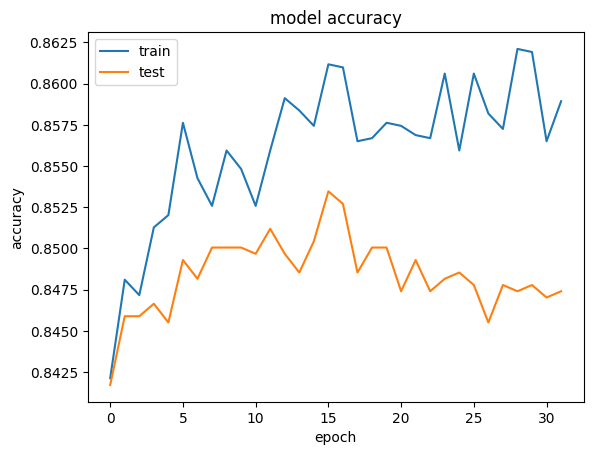

In [177]:
#summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

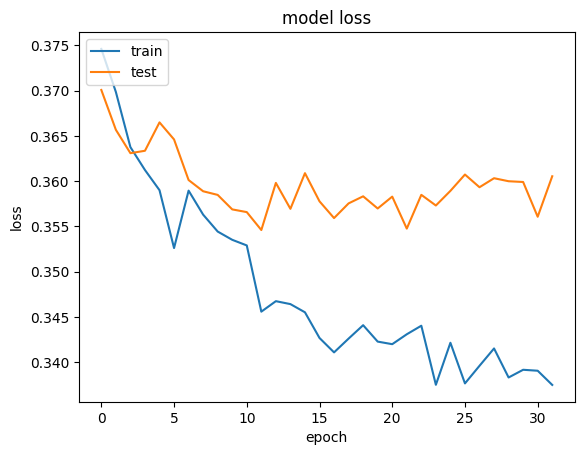

In [178]:
#summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()


In [179]:
#making the prediction and evaluation the model
y_pred=classifier.predict(X_test)
y_pred=(y_pred>0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [180]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred)
cm

array([[1537,   58],
       [ 218,  187]])

In [181]:
#Calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)
score

0.862

In [182]:
#get the weeight and store
classifier.get_weights()

[array([[ 5.56037612e-02,  8.32049772e-02,  1.98522061e-01,
          1.33891655e-02,  3.01657580e-02, -7.54672885e-02,
         -1.13263898e-01, -7.69780055e-02,  2.14812040e-01,
          5.80218248e-03, -2.12365258e-02],
        [ 6.88973069e-02,  3.32055181e-01, -6.16095960e-01,
         -7.65570819e-01, -5.15469909e-01,  3.66220064e-02,
         -8.86747912e-02,  8.32197130e-01,  1.16580436e-02,
          2.25329936e-01, -6.56699181e-01],
        [ 3.06561235e-02,  1.87952414e-01,  1.14920940e-02,
         -2.18969449e-01,  1.98520616e-01, -1.82059139e-01,
         -1.53102521e-02,  1.60794318e-01, -1.17382477e-03,
         -2.13912874e-01, -1.19859334e-02],
        [ 4.70067680e-01, -4.57894802e-01,  3.58579665e-01,
          8.06322172e-02, -7.16784149e-02,  8.98348913e-02,
         -2.88726449e-01,  4.29480255e-01,  3.40416312e-01,
         -4.10246193e-01, -9.47938338e-02],
        [ 9.60002780e-01,  8.71296152e-02, -3.12058717e-01,
          1.19714253e-02, -3.91950011e-02,  